# Notebook para entender o mercado futuro yfinance

### Vamos usar ES=F (S&P 500 Futures) porque ele é o melhor proxy de risk-on global.

1️⃣ Correlação e Tracking

2️⃣ Spread Futuro vs Spot (Basis)

3️⃣ Overnight Effect

4️⃣ Volatilidade Relativa

5️⃣ Drawdowns Sincronizados

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


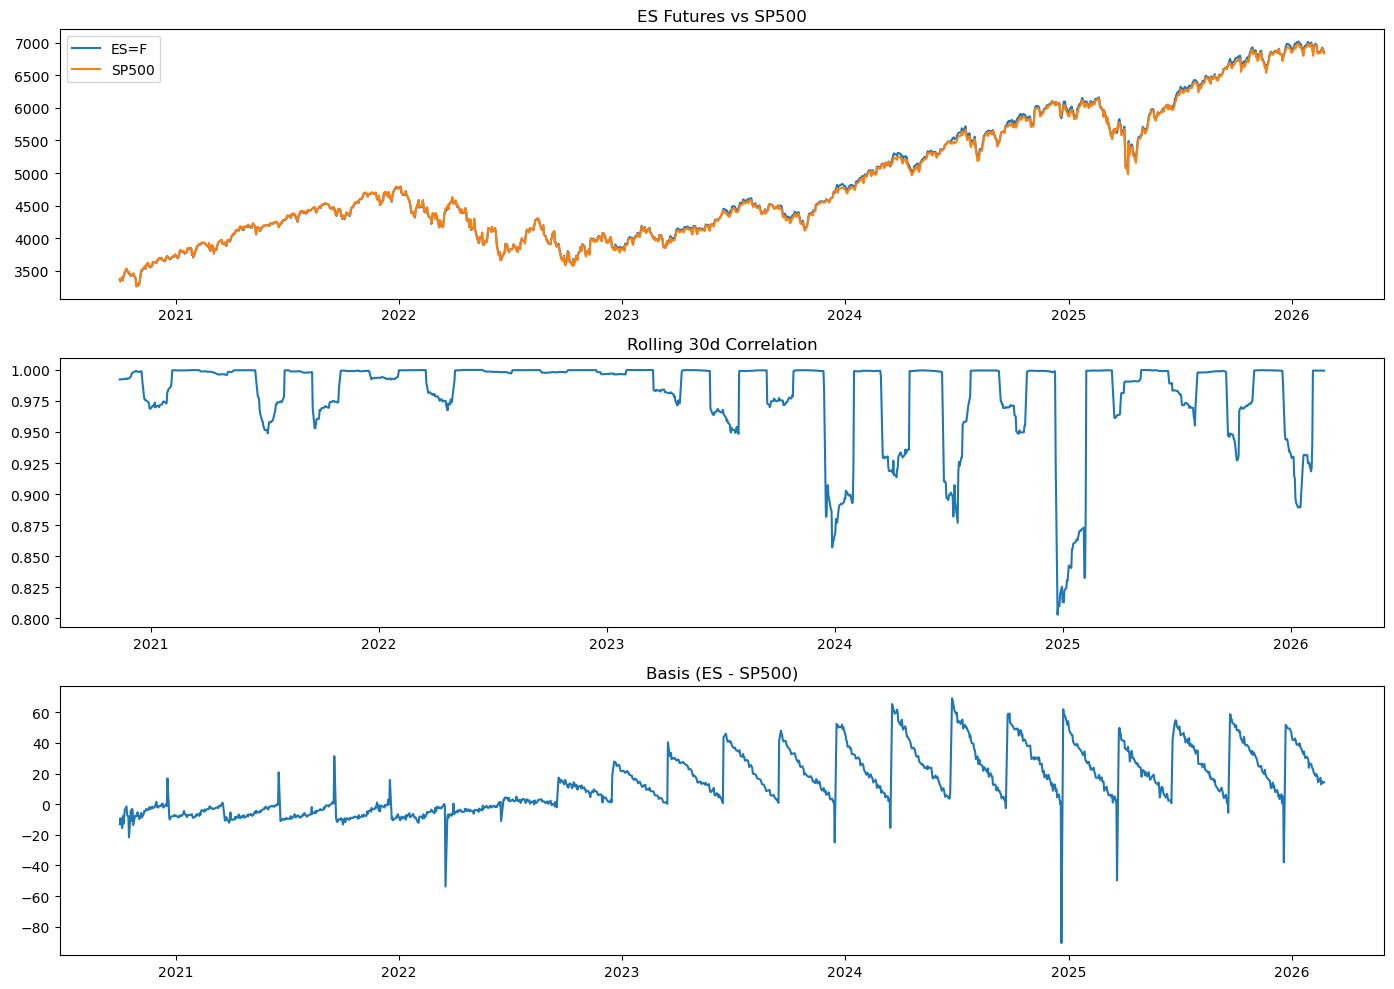

Correlação média: 0.9879648702846517


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

start_date = "2020-10-01"

# Download
es = yf.download("ES=F", start=start_date, interval="1d", auto_adjust=False)
spx = yf.download("^GSPC", start=start_date, interval="1d", auto_adjust=False)

# Garantir coluna simples
es_close = es["Close"].squeeze()
spx_close = spx["Close"].squeeze()

df = pd.DataFrame({
    "es_close": es_close,
    "spx_close": spx_close
}).dropna()

# Retornos
df["es_ret"] = df["es_close"].pct_change()
df["spx_ret"] = df["spx_close"].pct_change()

# Rolling correlação
df["rolling_corr_30"] = (
    df["es_ret"]
    .rolling(30)
    .corr(df["spx_ret"])
)

# Basis
df["basis"] = df["es_close"] - df["spx_close"]

# Volatilidade
df["es_vol_21"] = df["es_ret"].rolling(21).std()
df["spx_vol_21"] = df["spx_ret"].rolling(21).std()

# ---------------- PLOTS ----------------

plt.figure(figsize=(14,10))

plt.subplot(3,1,1)
plt.plot(df["es_close"], label="ES=F")
plt.plot(df["spx_close"], label="SP500")
plt.title("ES Futures vs SP500")
plt.legend()

plt.subplot(3,1,2)
plt.plot(df["rolling_corr_30"])
plt.title("Rolling 30d Correlation")

plt.subplot(3,1,3)
plt.plot(df["basis"])
plt.title("Basis (ES - SP500)")

plt.tight_layout()
plt.show()

print("Correlação média:", df["es_ret"].corr(df["spx_ret"]))

### corte de 2025-10 prara frente

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


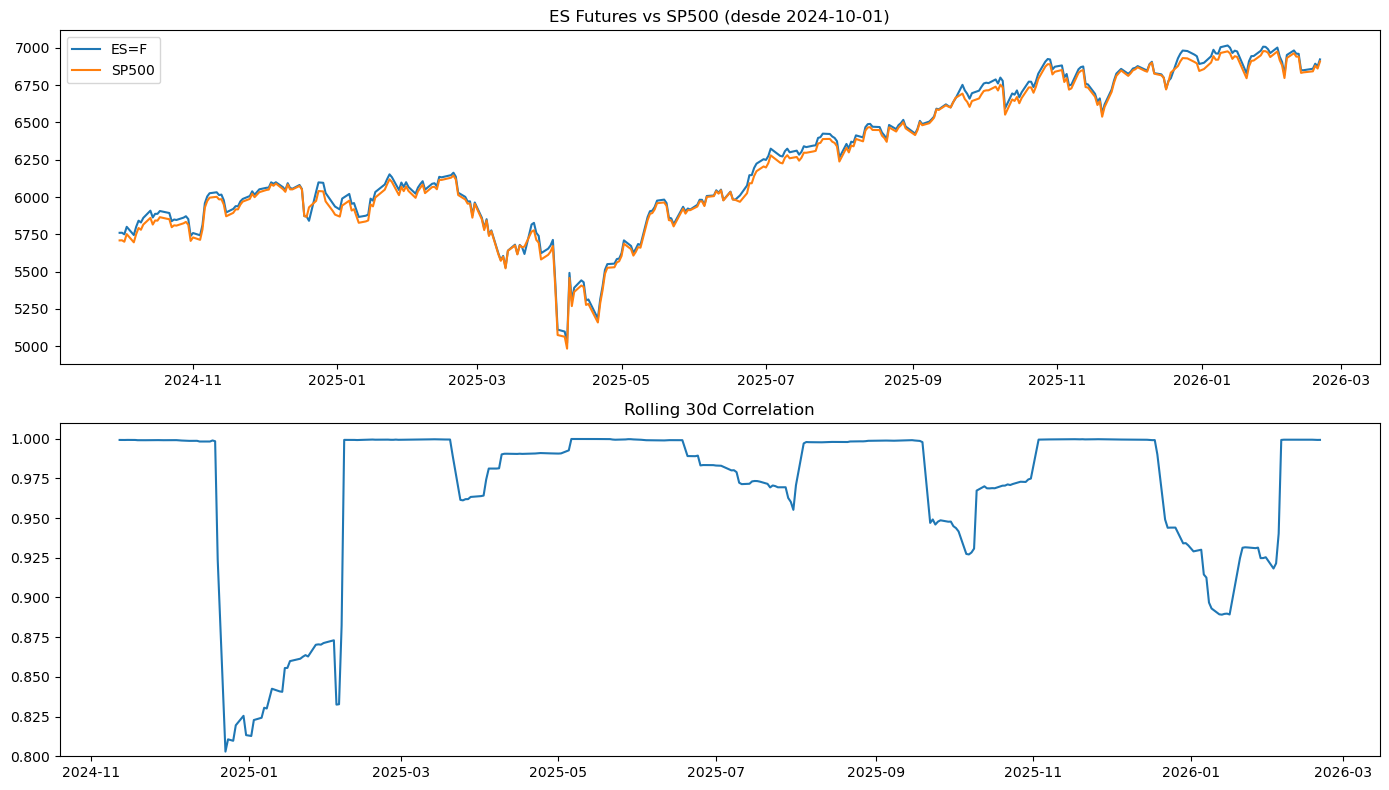

Correlação média: 0.9794818133521072


In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

start_date = "2024-10-01"

# Download
es = yf.download("ES=F", start=start_date, interval="1d", auto_adjust=False)
spx = yf.download("^GSPC", start=start_date, interval="1d", auto_adjust=False)

# Garantir Series 1D
es_close = es["Close"].squeeze()
spx_close = spx["Close"].squeeze()

df = pd.DataFrame({
    "es_close": es_close,
    "spx_close": spx_close
}).dropna()

# Retornos
df["es_ret"] = df["es_close"].pct_change()
df["spx_ret"] = df["spx_close"].pct_change()

# Rolling correlação
df["rolling_corr_30"] = (
    df["es_ret"]
    .rolling(30)
    .corr(df["spx_ret"])
)

# ---------------- PLOTS ----------------

plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
plt.plot(df["es_close"], label="ES=F")
plt.plot(df["spx_close"], label="SP500")
plt.title("ES Futures vs SP500 (desde 2024-10-01)")
plt.legend()

plt.subplot(2,1,2)
plt.plot(df["rolling_corr_30"])
plt.title("Rolling 30d Correlation")
plt.ylim(0.8, 1.01)

plt.tight_layout()
plt.show()

print("Correlação média:", df["es_ret"].corr(df["spx_ret"]))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


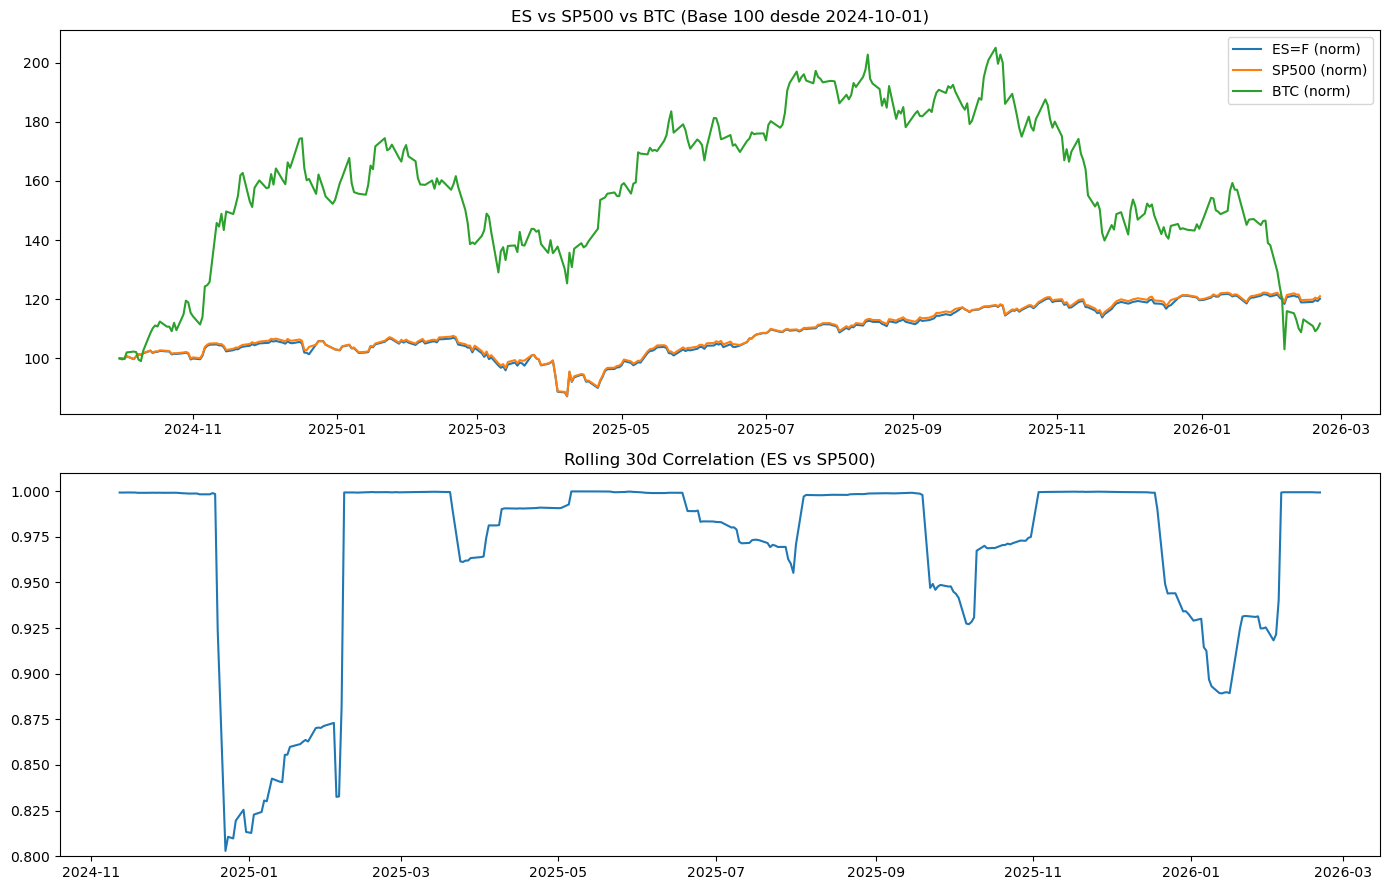

Correlação média ES vs SP500: 0.9794818133521072


In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

start_date = "2024-10-01"

# Download dados
es = yf.download("ES=F", start=start_date, interval="1d", auto_adjust=False)
spx = yf.download("^GSPC", start=start_date, interval="1d", auto_adjust=False)
btc = yf.download("BTC-USD", start=start_date, interval="1d", auto_adjust=False)

# Garantir Series
es_close = es["Close"].squeeze()
spx_close = spx["Close"].squeeze()
btc_close = btc["Close"].squeeze()

df = pd.DataFrame({
    "es": es_close,
    "spx": spx_close,
    "btc": btc_close
}).dropna()

# Normalização base 100
df_norm = df / df.iloc[0] * 100

# Retornos
df["es_ret"] = df["es"].pct_change()
df["spx_ret"] = df["spx"].pct_change()

# Rolling correlação
df["rolling_corr_30"] = (
    df["es_ret"]
    .rolling(30)
    .corr(df["spx_ret"])
)

# ---------------- PLOTS ----------------

plt.figure(figsize=(14,9))

plt.subplot(2,1,1)
plt.plot(df_norm["es"], label="ES=F (norm)")
plt.plot(df_norm["spx"], label="SP500 (norm)")
plt.plot(df_norm["btc"], label="BTC (norm)")
plt.title("ES vs SP500 vs BTC (Base 100 desde 2024-10-01)")
plt.legend()

plt.subplot(2,1,2)
plt.plot(df["rolling_corr_30"])
plt.title("Rolling 30d Correlation (ES vs SP500)")
plt.ylim(0.8, 1.01)

plt.tight_layout()
plt.show()

print("Correlação média ES vs SP500:", df["es_ret"].corr(df["spx_ret"]))

### Vamos calcular Rolling 30d Correlation BTC vs ES no mesmo período (desde 2024-10-01).

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


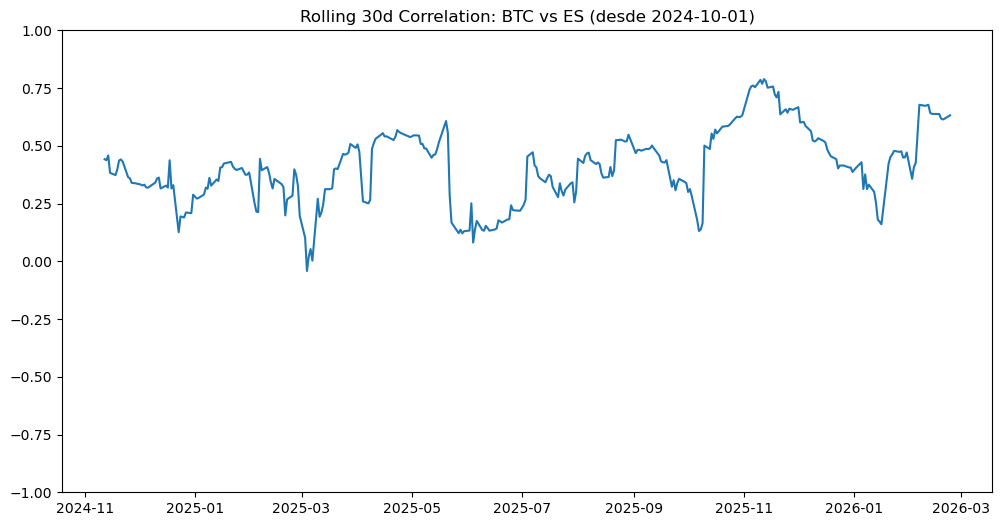

Correlação média BTC vs ES: 0.3946058616608747


In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

start_date = "2024-10-01"

# Download
es = yf.download("ES=F", start=start_date, interval="1d", auto_adjust=False)
btc = yf.download("BTC-USD", start=start_date, interval="1d", auto_adjust=False)

# Series
es_close = es["Close"].squeeze()
btc_close = btc["Close"].squeeze()

df = pd.DataFrame({
    "es": es_close,
    "btc": btc_close
}).dropna()

# Retornos
df["es_ret"] = df["es"].pct_change()
df["btc_ret"] = df["btc"].pct_change()

# Rolling correlation 30d
df["rolling_corr_30"] = (
    df["btc_ret"]
    .rolling(30)
    .corr(df["es_ret"])
)

# --------- Plot ---------

plt.figure(figsize=(12,6))
plt.plot(df["rolling_corr_30"])
plt.title("Rolling 30d Correlation: BTC vs ES (desde 2024-10-01)")
plt.ylim(-1, 1)
plt.show()

print("Correlação média BTC vs ES:", df["btc_ret"].corr(df["es_ret"]))

### ate onde temos informacao de futuros no yfinance

In [6]:
import yfinance as yf
import pandas as pd

start_date = "2020-10-01"

es = yf.download("ES=F", start=start_date, interval="1d", auto_adjust=False)
spx = yf.download("^GSPC", start=start_date, interval="1d", auto_adjust=False)

print("Última data SP500 (^GSPC):", spx.index.max())
print("Última data ES=F:", es.index.max())

# Checar se há datas além de hoje (não deveria haver)
today_utc = pd.Timestamp.utcnow().normalize()
print("Hoje (UTC):", today_utc)

print("SP500 tem dados futuros?", spx.index.max() > today_utc)
print("ES tem dados futuros?", es.index.max() > today_utc)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Última data SP500 (^GSPC): 2026-02-20 00:00:00
Última data ES=F: 2026-02-23 00:00:00
Hoje (UTC): 2026-02-23 00:00:00+00:00


TypeError: Cannot compare tz-naive and tz-aware timestamps

### validando primeira extracao do futures

In [11]:
import pandas as pd

file_path = "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/futures/crypto/perpetual/1h/BTCUSDT.parquet"

df = pd.read_parquet(file_path)

print("Shape:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nRange temporal:")
print("Min:", df["open_time"].min())
print("Max:", df["open_time"].max())

print("\nDuplicados open_time:", df["open_time"].duplicated().sum())
print("\nTimezone:", df["open_time"].dt.tz)

display(df.head())

Shape: (47325, 14)

Colunas:
['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore', 'symbol', 'extracted_at']

Range temporal:
Min: 2020-10-01 00:00:00+00:00
Max: 2026-02-23 20:00:00+00:00

Duplicados open_time: 0

Timezone: UTC


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore,symbol,extracted_at
0,2020-10-01 00:00:00+00:00,10773.00,10827.00,10773.00,10785.98,8068.478,2020-10-01 00:59:59.999000+00:00,8.714199e+07,28076,4426.127,4.780705e+07,0.0,BTCUSDT,2026-02-23 20:53:56.145152+00:00
1,2020-10-01 01:00:00+00:00,10785.99,10844.00,10782.83,10833.13,5354.699,2020-10-01 01:59:59.999000+00:00,5.791396e+07,21924,3337.519,3.609825e+07,0.0,BTCUSDT,2026-02-23 20:53:56.145152+00:00
2,2020-10-01 02:00:00+00:00,10833.13,10850.00,10805.01,10814.53,5453.863,2020-10-01 02:59:59.999000+00:00,5.903546e+07,23203,2883.450,3.121976e+07,0.0,BTCUSDT,2026-02-23 20:53:56.145152+00:00
3,2020-10-01 03:00:00+00:00,10814.53,10820.00,10788.52,10795.17,3063.348,2020-10-01 03:59:59.999000+00:00,3.308306e+07,17924,1604.909,1.733248e+07,0.0,BTCUSDT,2026-02-23 20:53:56.145152+00:00
4,2020-10-01 04:00:00+00:00,10795.17,10823.41,10791.27,10795.69,3325.366,2020-10-01 04:59:59.999000+00:00,3.593887e+07,15689,1710.625,1.848877e+07,0.0,BTCUSDT,2026-02-23 20:53:56.145152+00:00


### testando o futuros de btc

Vamos calcular:

- Return 1h
- Vol 24h
- Volume 24h
- ELR_proxy
- Correlação rolling entre ELR_proxy e vol

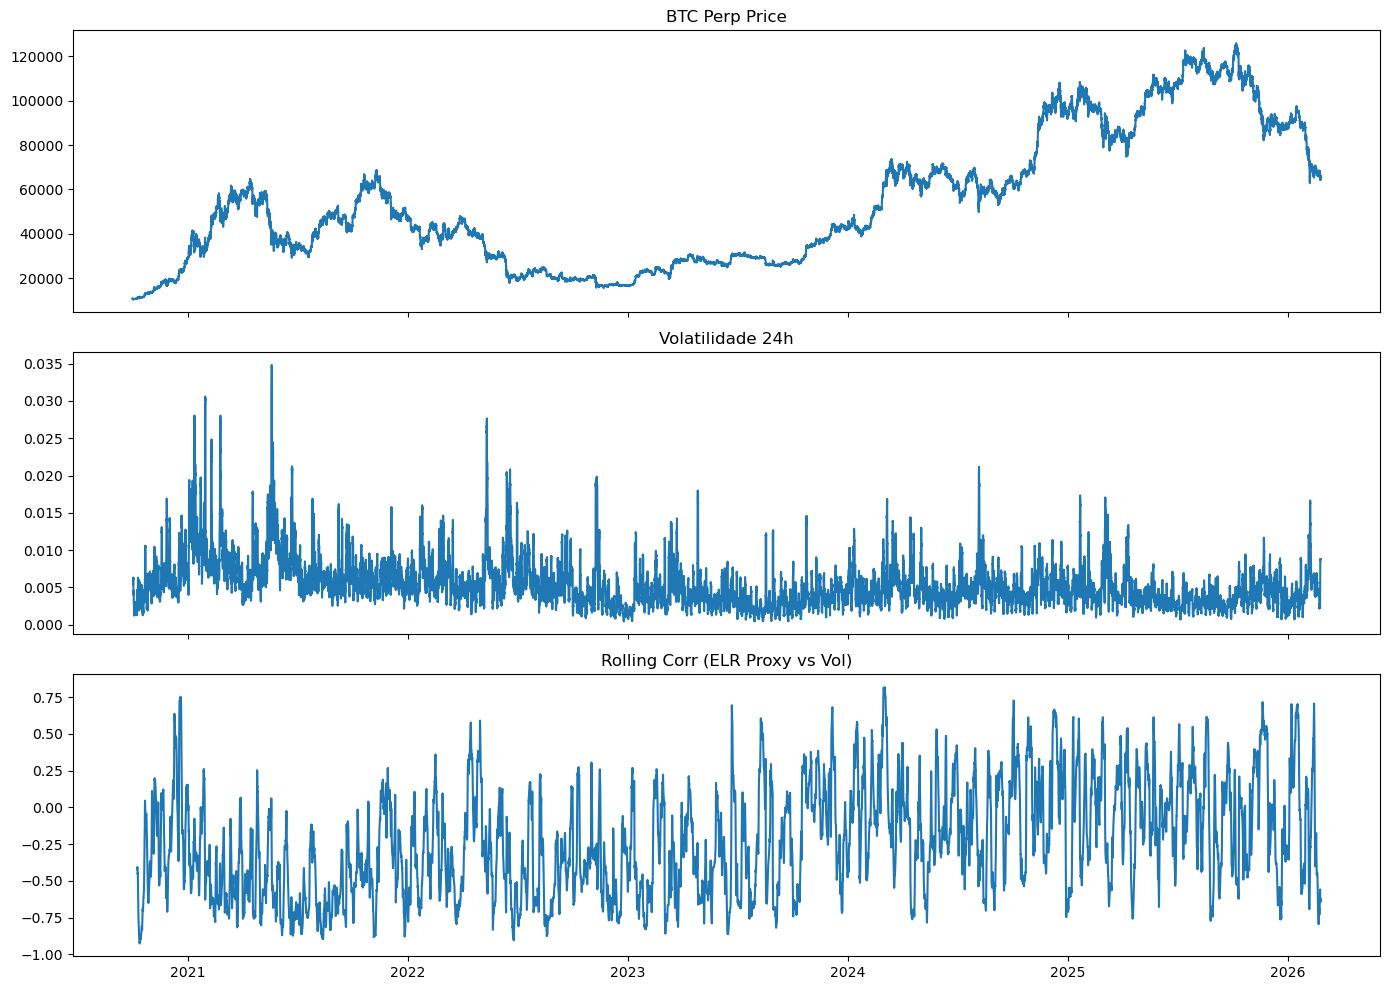

Correlação média ELR vs Vol: -0.365620165897188


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregar dados
file_path = "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/futures/crypto/perpetual/1h/BTCUSDT.parquet"
df = pd.read_parquet(file_path)

df = df.sort_values("open_time").reset_index(drop=True)

# -------------------------
# 1. Retorno 1h
# -------------------------
df["return_1h"] = df["close"].pct_change()

# -------------------------
# 2. Volatilidade rolling 24h
# -------------------------
df["vol_24h"] = df["return_1h"].rolling(24).std()

# -------------------------
# 3. Volume nocional 24h
# -------------------------
df["volume_24h"] = df["quote_asset_volume"].rolling(24).sum()

# -------------------------
# 4. Proxy ELR
# -------------------------
df["elr_proxy"] = df["volume_24h"] / df["vol_24h"]

# -------------------------
# 5. Correlação rolling 7 dias
# -------------------------
df["corr_elr_vol"] = df["elr_proxy"].rolling(24*7).corr(df["vol_24h"])

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df["open_time"], df["close"])
axes[0].set_title("BTC Perp Price")

axes[1].plot(df["open_time"], df["vol_24h"])
axes[1].set_title("Volatilidade 24h")

axes[2].plot(df["open_time"], df["corr_elr_vol"])
axes[2].set_title("Rolling Corr (ELR Proxy vs Vol)")

plt.tight_layout()
plt.show()

print("Correlação média ELR vs Vol:",
      df[["elr_proxy", "vol_24h"]].corr().iloc[0,1])

In [13]:
import requests
import pandas as pd
from datetime import datetime, timezone

BASE_URL = "https://fapi.binance.com"
ENDPOINT = "/futures/data/openInterestHist"

params = {
    "symbol": "BTCUSDT",
    "period": "1h",
    "limit": 30,   # teste pequeno primeiro
    # "startTime": int(pd.Timestamp("2023-01-01", tz="UTC").timestamp() * 1000),
}

url = BASE_URL + ENDPOINT

try:
    response = requests.get(url, params=params, timeout=10)
    response.raise_for_status()
    data = response.json()
    
    print("Status:", response.status_code)
    print("Rows returned:", len(data))
    
    df = pd.DataFrame(data)
    
    if not df.empty:
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
        df["sumOpenInterest"] = df["sumOpenInterest"].astype(float)
        df["sumOpenInterestValue"] = df["sumOpenInterestValue"].astype(float)
        
        display(df.head())
    else:
        print("Empty response.")

except requests.exceptions.RequestException as e:
    print("Request failed:", e)

Status: 200
Rows returned: 30


,symbol,sumOpenInterest,sumOpenInterestValue,CMCCirculatingSupply,timestamp
0,BTCUSDT,79369.228,5.350116e+09,19992875.00000000,2026-02-22 19:00:00+00:00
1,BTCUSDT,79411.215,5.352491e+09,19992875.00000000,2026-02-22 20:00:00+00:00
2,BTCUSDT,79292.781,5.341867e+09,19992875.00000000,2026-02-22 21:00:00+00:00
3,BTCUSDT,79065.680,5.342963e+09,19992875.00000000,2026-02-22 22:00:00+00:00
4,BTCUSDT,78935.133,5.338478e+09,19992875.00000000,2026-02-22 23:00:00+00:00


In [14]:
import requests
import pandas as pd
import time

BASE_URL = "https://fapi.binance.com"
ENDPOINT = "/futures/data/openInterestHist"

symbol = "BTCUSDT"
period = "1h"
limit = 500  # máximo permitido

all_rows = []
current_start = None  # começamos sem startTime
max_pages = 50  # segurança contra loop infinito

for i in range(max_pages):
    params = {
        "symbol": symbol,
        "period": period,
        "limit": limit,
    }
    
    if current_start:
        params["endTime"] = current_start

    response = requests.get(BASE_URL + ENDPOINT, params=params, timeout=10)
    
    if response.status_code != 200:
        print("Erro:", response.status_code)
        break

    data = response.json()
    
    if not data:
        print("Sem mais dados.")
        break

    df_page = pd.DataFrame(data)
    all_rows.append(df_page)

    # Pegamos o timestamp mais antigo da página atual
    oldest_ts = df_page["timestamp"].astype(int).min()
    
    # Próxima requisição vai pedir dados anteriores
    current_start = oldest_ts - 1

    print(f"Página {i+1} | Mais antigo nesta página: {pd.to_datetime(oldest_ts, unit='ms', utc=True)}")

    time.sleep(0.3)

# Consolidar tudo
if all_rows:
    df_all = pd.concat(all_rows, ignore_index=True)
    df_all["timestamp"] = pd.to_datetime(df_all["timestamp"].astype(int), unit="ms", utc=True)

    print("\n===== RESULTADO FINAL =====")
    print("Data mais antiga disponível:")
    print(df_all["timestamp"].min())

    print("\nData mais recente disponível:")
    print(df_all["timestamp"].max())

    print("\nTotal de registros coletados:", len(df_all))

Página 1 | Mais antigo nesta página: 2026-02-03 05:00:00+00:00
Página 2 | Mais antigo nesta página: 2026-01-24 01:00:00+00:00
Sem mais dados.

===== RESULTADO FINAL =====
Data mais antiga disponível:
2026-01-24 01:00:00+00:00

Data mais recente disponível:
2026-02-24 00:00:00+00:00

Total de registros coletados: 744


### testando o historico do Funding Rate 

In [15]:
import requests
import pandas as pd
import time

BASE_URL = "https://fapi.binance.com"
ENDPOINT = "/fapi/v1/fundingRate"

symbol = "BTCUSDT"
limit = 1000  # máximo permitido por request

all_rows = []
start_time = None  # vamos paginar para trás
max_pages = 50     # segurança

for i in range(max_pages):
    params = {
        "symbol": symbol,
        "limit": limit,
    }
    
    if start_time:
        params["endTime"] = start_time

    response = requests.get(BASE_URL + ENDPOINT, params=params, timeout=10)
    
    if response.status_code != 200:
        print("Erro:", response.status_code)
        break

    data = response.json()
    
    if not data:
        print("Sem mais dados.")
        break

    df_page = pd.DataFrame(data)
    all_rows.append(df_page)

    # pegar fundingTime mais antigo da página
    oldest_ts = df_page["fundingTime"].astype(int).min()
    start_time = oldest_ts - 1

    print(f"Página {i+1} | Mais antigo nesta página:",
          pd.to_datetime(oldest_ts, unit="ms", utc=True))

    time.sleep(0.3)

# Consolidar
if all_rows:
    df_all = pd.concat(all_rows, ignore_index=True)
    df_all["fundingTime"] = pd.to_datetime(
        df_all["fundingTime"].astype(int), unit="ms", utc=True
    )
    df_all["fundingRate"] = df_all["fundingRate"].astype(float)

    print("\n===== RESULTADO FINAL =====")
    print("Data mais antiga disponível:", df_all["fundingTime"].min())
    print("Data mais recente disponível:", df_all["fundingTime"].max())
    print("Total de registros:", len(df_all))

    display(df_all.sort_values("fundingTime").head())

Página 1 | Mais antigo nesta página: 2025-12-19 16:00:00+00:00
Página 2 | Mais antigo nesta página: 2019-09-10 08:00:00+00:00
Sem mais dados.

===== RESULTADO FINAL =====
Data mais antiga disponível: 2019-09-10 08:00:00+00:00
Data mais recente disponível: 2026-02-24 00:00:00.007000+00:00
Total de registros: 1200


,symbol,fundingTime,fundingRate,markPrice
200,BTCUSDT,2019-09-10 08:00:00+00:00,0.0001,
201,BTCUSDT,2019-09-10 16:00:00+00:00,0.0001,
202,BTCUSDT,2019-09-11 00:00:00+00:00,0.0001,
203,BTCUSDT,2019-09-11 08:00:00+00:00,0.0001,
204,BTCUSDT,2019-09-11 16:00:00+00:00,0.0001,


### Verificando Funding Rates

In [4]:
import pandas as pd
from pathlib import Path

# Caminho do arquivo
file_path = Path(
    "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/futures/crypto/funding/BTCUSDT.parquet"
)

# ==============================
# Load
# ==============================

df = pd.read_parquet(file_path)

print("\n=== HEAD ===")
print(df.head())

print("\n=== INFO ===")
print(df.info())

print("\n=== DTYPES ===")
print(df.dtypes)

# ==============================
# Schema Checks
# ==============================

expected_columns = {
    "open_time",
    "fundingRate",
    "symbol",
    "extracted_at",
}

print("\n=== COLUMN CHECK ===")
print("Missing columns:", expected_columns - set(df.columns))
print("Extra columns:", set(df.columns) - expected_columns)

# ==============================
# UTC Validation
# ==============================

print("\n=== UTC CHECK ===")
print("open_time tz:", df["open_time"].dt.tz)
print("extracted_at tz:", df["extracted_at"].dt.tz)

# ==============================
# Ordering Check
# ==============================

is_sorted = df["open_time"].is_monotonic_increasing
print("\n=== SORT CHECK ===")
print("Is sorted ascending:", is_sorted)

# ==============================
# Duplicates Check
# ==============================

duplicates = df.duplicated(subset=["open_time"]).sum()
print("\n=== DUPLICATE CHECK ===")
print("Duplicate open_time rows:", duplicates)

# ==============================
# Null Analysis
# ==============================

print("\n=== NULL RATIO ===")
print(df.isna().mean())

# ==============================
# Range
# ==============================

print("\n=== TIME RANGE ===")
print("Start:", df["open_time"].min())
print("End  :", df["open_time"].max())

print("\n=== ROW COUNT ===")
print(len(df))


=== HEAD ===
    symbol                        open_time  fundingRate  markPrice  \
0  BTCUSDT        2020-10-01 00:00:00+00:00     0.000074        NaN   
1  BTCUSDT        2020-10-01 08:00:00+00:00     0.000100        NaN   
2  BTCUSDT        2020-10-01 16:00:00+00:00     0.000100        NaN   
3  BTCUSDT 2020-10-02 00:00:00.011000+00:00    -0.000003        NaN   
4  BTCUSDT        2020-10-02 08:00:00+00:00    -0.000017        NaN   

                      extracted_at  
0 2026-02-25 20:53:52.170181+00:00  
1 2026-02-25 20:53:52.170181+00:00  
2 2026-02-25 20:53:52.170181+00:00  
3 2026-02-25 20:53:52.170181+00:00  
4 2026-02-25 20:53:52.170181+00:00  

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5922 entries, 0 to 5921
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   symbol        5922 non-null   object             
 1   open_time     5922 non-null   datetime64[ns, UT

In [5]:
import requests
import pandas as pd
from datetime import datetime, timezone, timedelta

BASE_URL = "https://fapi.binance.com"
ENDPOINT = "/futures/data/takerlongshortRatio"

symbol = "BTCUSDT"
period = "1h"
limit = 500

def test_start_date(start_date_str):
    start_dt = pd.Timestamp(start_date_str, tz="UTC")
    start_ms = int(start_dt.timestamp() * 1000)

    params = {
        "symbol": symbol,
        "period": period,
        "limit": limit,
        "startTime": start_ms,
    }

    url = BASE_URL + ENDPOINT
    r = requests.get(url, params=params, timeout=10)

    print(f"\nTesting start_date: {start_date_str}")
    print("Status Code:", r.status_code)

    if r.status_code == 200:
        data = r.json()
        print("Rows returned:", len(data))
        if data:
            first_ts = pd.to_datetime(data[0]["timestamp"], unit="ms", utc=True)
            last_ts = pd.to_datetime(data[-1]["timestamp"], unit="ms", utc=True)
            print("First returned timestamp:", first_ts)
            print("Last returned timestamp:", last_ts)
    else:
        print("Error response:", r.text)


# Testes progressivos no tempo
test_dates = [
    "2020-10-01",
    "2022-01-01",
    "2023-01-01",
    "2024-01-01",
    (pd.Timestamp.utcnow() - pd.Timedelta(days=60)).strftime("%Y-%m-%d"),
    (pd.Timestamp.utcnow() - pd.Timedelta(days=30)).strftime("%Y-%m-%d"),
    (pd.Timestamp.utcnow() - pd.Timedelta(days=7)).strftime("%Y-%m-%d"),
]

for d in test_dates:
    test_start_date(d)


Testing start_date: 2020-10-01
Status Code: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

Testing start_date: 2022-01-01
Status Code: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

Testing start_date: 2023-01-01
Status Code: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

Testing start_date: 2024-01-01
Status Code: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

Testing start_date: 2025-12-27
Status Code: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

Testing start_date: 2026-01-26
Status Code: 200
Rows returned: 500
First returned timestamp: 2026-02-05 01:00:00+00:00
Last returned timestamp: 2026-02-25 20:00:00+00:00

Testing start_date: 2026-02-18
Status Code: 200
Rows returned: 190
First returned timestamp: 2026-02-17 23:00:00+00:00
Last returned timestamp: 2026-02-25 20:00:00+00:00


### Open Interest histórico da Binance Futures

In [6]:
import requests
import pandas as pd

BASE_URL = "https://fapi.binance.com"

symbol = "BTCUSDT"

def test_open_interest_snapshot():
    print("\n=== Testing /fapi/v1/openInterest (snapshot) ===")
    url = BASE_URL + "/fapi/v1/openInterest"
    params = {"symbol": symbol}
    r = requests.get(url, params=params, timeout=10)
    print("Status:", r.status_code)
    print("Response:", r.json())


def test_open_interest_hist(start_date):
    print(f"\n=== Testing /futures/data/openInterestHist from {start_date} ===")
    
    start_dt = pd.Timestamp(start_date, tz="UTC")
    start_ms = int(start_dt.timestamp() * 1000)

    url = BASE_URL + "/futures/data/openInterestHist"
    params = {
        "symbol": symbol,
        "period": "1h",
        "limit": 500,
        "startTime": start_ms,
    }

    r = requests.get(url, params=params, timeout=10)
    print("Status:", r.status_code)

    if r.status_code == 200:
        data = r.json()
        print("Rows returned:", len(data))
        if data:
            first_ts = pd.to_datetime(data[0]["timestamp"], unit="ms", utc=True)
            last_ts = pd.to_datetime(data[-1]["timestamp"], unit="ms", utc=True)
            print("First returned timestamp:", first_ts)
            print("Last returned timestamp:", last_ts)
    else:
        print("Error response:", r.text)


# ---- RUN TESTS ----

test_open_interest_snapshot()

# Testando datas antigas
test_open_interest_hist("2020-10-01")
test_open_interest_hist("2023-01-01")
test_open_interest_hist("2024-01-01")

# Testando janelas recentes
test_open_interest_hist(
    (pd.Timestamp.utcnow() - pd.Timedelta(days=60)).strftime("%Y-%m-%d")
)
test_open_interest_hist(
    (pd.Timestamp.utcnow() - pd.Timedelta(days=30)).strftime("%Y-%m-%d")
)
test_open_interest_hist(
    (pd.Timestamp.utcnow() - pd.Timedelta(days=7)).strftime("%Y-%m-%d")
)


=== Testing /fapi/v1/openInterest (snapshot) ===
Status: 200
Response: {'symbol': 'BTCUSDT', 'openInterest': '80254.961', 'time': 1772056841692}

=== Testing /futures/data/openInterestHist from 2020-10-01 ===
Status: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

=== Testing /futures/data/openInterestHist from 2023-01-01 ===
Status: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

=== Testing /futures/data/openInterestHist from 2024-01-01 ===
Status: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

=== Testing /futures/data/openInterestHist from 2025-12-27 ===
Status: 400
Error response: {"msg":"parameter 'startTime' is invalid.","code":-1130}

=== Testing /futures/data/openInterestHist from 2026-01-26 ===
Status: 200
Rows returned: 500
First returned timestamp: 2026-02-05 03:00:00+00:00
Last returned timestamp: 2026-02-25 22:00:00+00:00

=== Testing /futures/data/openInterestHist from 2026-02-18 

### testando outra fonte de dados deribit

In [9]:
import requests
import json
import pandas as pd

BASE_URL = "https://www.deribit.com/api/v2"
instrument = "BTC-PERPETUAL"

url = BASE_URL + "/public/get_book_summary_by_instrument"
params = {"instrument_name": instrument}

r = requests.get(url, params=params, timeout=10)

print("Status:", r.status_code)

data = r.json()

# Pretty print completo
print("\n=== RAW JSON ===\n")
print(json.dumps(data, indent=2))

# Listar apenas as chaves do objeto principal
if "result" in data and len(data["result"]) > 0:
    print("\n=== AVAILABLE FIELDS ===\n")
    for key in data["result"][0].keys():
        print("-", key)

Status: 200

=== RAW JSON ===

{
  "jsonrpc": "2.0",
  "result": [
    {
      "high": 70211.5,
      "low": 63823.5,
      "last": 69156.5,
      "instrument_name": "BTC-PERPETUAL",
      "bid_price": 69163.0,
      "ask_price": 69163.5,
      "open_interest": 1156369330,
      "mark_price": 69157.42,
      "creation_timestamp": 1772057570792,
      "price_change": 7.7926,
      "volume": 15922.54672732,
      "estimated_delivery_price": 69171.88,
      "base_currency": "BTC",
      "quote_currency": "USD",
      "volume_usd": 1065677970.0,
      "volume_notional": 1065677970.0,
      "current_funding": 0.0,
      "funding_8h": -9.11e-06,
      "mid_price": 69163.25
    }
  ],
  "usIn": 1772057570791966,
  "usOut": 1772057570792143,
  "usDiff": 177,
  "testnet": false
}

=== AVAILABLE FIELDS ===

- high
- low
- last
- instrument_name
- bid_price
- ask_price
- open_interest
- mark_price
- creation_timestamp
- price_change
- volume
- estimated_delivery_price
- base_currency
- quote_curr

In [10]:
import requests
import json
import pandas as pd

BASE_URL = "https://www.deribit.com/api/v2"
instrument = "BTC-PERPETUAL"

endpoints = {
    "book_summary_by_instrument": {
        "url": "/public/get_book_summary_by_instrument",
        "params": {"instrument_name": instrument},
    },
    "book_summary_by_currency": {
        "url": "/public/get_book_summary_by_currency",
        "params": {"currency": "BTC", "kind": "future"},
    },
    "ticker": {
        "url": "/public/ticker",
        "params": {"instrument_name": instrument},
    },
    "instrument_state": {
        "url": "/public/get_instrument",
        "params": {"instrument_name": instrument},
    },
    "instrument_stats": {
        "url": "/public/get_instrument_stats",
        "params": {"instrument_name": instrument},
    },
}

for name, config in endpoints.items():
    print(f"\n==============================")
    print(f"Testing endpoint: {name}")
    print("==============================")

    url = BASE_URL + config["url"]

    try:
        r = requests.get(url, params=config["params"], timeout=10)
        print("Status:", r.status_code)

        if r.status_code != 200:
            print("Error:", r.text)
            continue

        data = r.json()

        print("\nAvailable top-level keys:")
        print(list(data.keys()))

        if "result" in data:
            result = data["result"]

            if isinstance(result, list) and len(result) > 0:
                print("\nFields in first result object:")
                print(list(result[0].keys()))
            elif isinstance(result, dict):
                print("\nFields in result object:")
                print(list(result.keys()))

        print("\nRaw snippet:")
        print(json.dumps(data, indent=2)[:800], "...")

    except Exception as e:
        print("Exception:", e)


Testing endpoint: book_summary_by_instrument
Status: 200

Available top-level keys:
['jsonrpc', 'result', 'usIn', 'usOut', 'usDiff', 'testnet']

Fields in first result object:
['high', 'low', 'last', 'instrument_name', 'bid_price', 'ask_price', 'open_interest', 'mark_price', 'creation_timestamp', 'price_change', 'volume', 'estimated_delivery_price', 'base_currency', 'quote_currency', 'volume_usd', 'volume_notional', 'current_funding', 'funding_8h', 'mid_price']

Raw snippet:
{
  "jsonrpc": "2.0",
  "result": [
    {
      "high": 70211.5,
      "low": 63823.5,
      "last": 69062.0,
      "instrument_name": "BTC-PERPETUAL",
      "bid_price": 69061.5,
      "ask_price": 69062.0,
      "open_interest": 1156382870,
      "mark_price": 69053.77,
      "creation_timestamp": 1772057779837,
      "price_change": 7.5732,
      "volume": 15924.95944441,
      "estimated_delivery_price": 69065.03,
      "base_currency": "BTC",
      "quote_currency": "USD",
      "volume_usd": 1065914420.0,
  

In [4]:
# ============================================================
# COINGLASS — Open Interest History
# Params confirmados da documentação oficial
# Rate limit: 30 req/min → sleep 2.5s entre requests
# ============================================================

import requests, os, time, pandas as pd
from pathlib import Path

KEY     = "cb3308a2ffd147a1aa9153dbd7d1b674"
BASE    = "https://open-api-v4.coinglass.com"
HEADERS = {"CG-API-KEY": KEY, "Accept": "application/json"}
SLEEP   = 2.5

START_MS = int(pd.Timestamp("2020-10-01", tz="UTC").timestamp() * 1000)
END_MS   = int(pd.Timestamp.now(tz="UTC").timestamp() * 1000)

def get(path, params):
    url = BASE + path
    for attempt in range(3):
        try:
            r = requests.get(url, headers=HEADERS,
                             params=params, timeout=30)
            print(f"  [{r.status_code}] {path} | params={params}")
            if r.status_code == 429:
                print("  Rate limit — aguardando 60s")
                time.sleep(60)
                continue
            return r.json()
        except Exception as e:
            print(f"  Erro tentativa {attempt+1}: {e}")
            time.sleep(5)
    return None

In [5]:
# ============================================================
# CÉLULA 1 — Teste rápido com params corretos
# ============================================================

time.sleep(SLEEP)
resp = get("/api/futures/open-interest/history", {
    "exchange": "Binance",
    "symbol":   "BTCUSDT",
    "interval": "1d",
    "limit":    5,
    "unit":     "usd",
})
print(f"\ncode={resp.get('code')} | data_len={len(resp.get('data', []))}")
if resp.get("data"):
    print("Primeiro:", resp["data"][0])
    print("Último:  ", resp["data"][-1])
    

  [200] /api/futures/open-interest/history | params={'exchange': 'Binance', 'symbol': 'BTCUSDT', 'interval': '1d', 'limit': 5, 'unit': 'usd'}

code=0 | data_len=5
Primeiro: {'time': 1772323200000, 'open': '5162346992', 'high': '5338629634', 'low': '5058115787', 'close': '5116675780'}
Último:   {'time': 1772668800000, 'open': '6649390277', 'high': '6686978593', 'low': '5943419525', 'close': 5949391051.3355}


In [6]:
# ============================================================
# CÉLULA 2 — Verificar alcance histórico
# Quantos dias retorna com limit=1000?
# ============================================================

time.sleep(SLEEP)
resp = get("/api/futures/open-interest/history", {
    "exchange":   "Binance",
    "symbol":     "BTCUSDT",
    "interval":   "1d",
    "limit":      1000,
    "start_time": START_MS,
    "end_time":   END_MS,
    "unit":       "usd",
})

data = resp.get("data", [])
print(f"Rows retornados: {len(data)}")
if data:
    t_first = pd.to_datetime(data[0]["time"],  unit="ms", utc=True)
    t_last  = pd.to_datetime(data[-1]["time"], unit="ms", utc=True)
    print(f"Range: {t_first.date()} → {t_last.date()}")
    print(f"Cobre histórico desde 2020-10? {'Sim' if t_first.year <= 2020 else 'NÃO — precisa paginar'}")

  [200] /api/futures/open-interest/history | params={'exchange': 'Binance', 'symbol': 'BTCUSDT', 'interval': '1d', 'limit': 1000, 'start_time': 1601510400000, 'end_time': 1772747082668, 'unit': 'usd'}
Rows retornados: 1982
Range: 2020-10-01 → 2026-03-05
Cobre histórico desde 2020-10? Sim


In [7]:
# ============================================================
# CÉLULA 3 — Download com paginação
# limit=1000 por janela, deslizando start_time
# ============================================================

def download_oi_full(exchange, symbol, start_ms, end_ms):
    all_data = []
    current_start = start_ms
    page = 0

    while current_start < end_ms:
        time.sleep(SLEEP)
        resp = get("/api/futures/open-interest/history", {
            "exchange":   exchange,
            "symbol":     symbol,
            "interval":   "1d",
            "limit":      1000,
            "start_time": current_start,
            "end_time":   end_ms,
            "unit":       "usd",
        })

        data = resp.get("data", []) if resp else []
        if not data:
            print(f"  Página {page}: sem dados — encerrando")
            break

        all_data.extend(data)
        page += 1

        # Próxima janela começa após o último timestamp retornado
        last_ts = data[-1]["time"]
        print(f"  Página {page}: {len(data)} rows | até {pd.to_datetime(last_ts, unit='ms', utc=True).date()}")

        # Se retornou menos que 1000, chegou ao fim
        if len(data) < 1000:
            break

        # Avançar 1ms para não repetir o último ponto
        current_start = last_ts + 1

    return all_data

print("Iniciando download BTC Open Interest...")
raw_data = download_oi_full(
    exchange  = "Binance",
    symbol    = "BTCUSDT",
    start_ms  = START_MS,
    end_ms    = END_MS,
)
print(f"\nTotal rows coletados: {len(raw_data)}")

Iniciando download BTC Open Interest...
  [200] /api/futures/open-interest/history | params={'exchange': 'Binance', 'symbol': 'BTCUSDT', 'interval': '1d', 'limit': 1000, 'start_time': 1601510400000, 'end_time': 1772747082668, 'unit': 'usd'}
  Página 1: 1982 rows | até 2026-03-05
  [200] /api/futures/open-interest/history | params={'exchange': 'Binance', 'symbol': 'BTCUSDT', 'interval': '1d', 'limit': 1000, 'start_time': 1772668800001, 'end_time': 1772747082668, 'unit': 'usd'}
  Página 2: 1 rows | até 2026-03-05

Total rows coletados: 1983


In [8]:
# ============================================================
# CÉLULA 4 — Parsear e validar
# ============================================================

df = pd.DataFrame(raw_data)

df["date"] = pd.to_datetime(df["time"], unit="ms", utc=True).dt.normalize()
df = df.set_index("date").sort_index()
df = df.drop(columns=["time"])

for col in ["open", "high", "low", "close"]:
    df[col] = df[col].astype(float)

df = df.rename(columns={"close": "open_interest_usd"})
df = df[~df.index.duplicated(keep="last")]

print(f"Shape:       {df.shape}")
print(f"Range:       {df.index.min().date()} → {df.index.max().date()}")
print(f"Colunas:     {df.columns.tolist()}")
print(f"NaN:         {df.isna().sum().sum()}")
print(f"Fins semana: {len(df[df.index.dayofweek >= 5])}")
print(f"\nHead:\n{df.head(3)}")
print(f"\nTail:\n{df.tail(3)}")
print(f"\nDescrição:\n{df['open_interest_usd'].describe()}")

Shape:       (1982, 4)
Range:       2020-10-01 → 2026-03-05
Colunas:     ['open', 'high', 'low', 'open_interest_usd']
NaN:         0
Fins semana: 566

Head:
                                  open         high          low  \
date                                                               
2020-10-01 00:00:00+00:00  386257674.0  401078952.0  370142500.0   
2020-10-02 00:00:00+00:00  377557581.0  403379762.0  377411953.0   
2020-10-03 00:00:00+00:00  392882926.0  400120087.0  390535887.0   

                           open_interest_usd  
date                                          
2020-10-01 00:00:00+00:00        375822061.0  
2020-10-02 00:00:00+00:00        395430245.0  
2020-10-03 00:00:00+00:00        393917702.0  

Tail:
                                   open          high           low  \
date                                                                  
2026-03-03 00:00:00+00:00  5.656152e+09  5.688801e+09  5.157331e+09   
2026-03-04 00:00:00+00:00  5.404459e+09  6.8666

In [11]:
# ============================================================
# CÉLULA 5 — Salvar
# ============================================================

out = Path("data/01_raw/derivatives/coinglass/open_interest/BTCUSDT.parquet")
out.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(out, compression="snappy")

df_check = pd.read_parquet(out)
print(f"Salvo e verificado: {df_check.shape} | tz={df_check.index.tz}")
print(f"Path: {out}")

Salvo e verificado: (1982, 4) | tz=UTC
Path: data/01_raw/derivatives/coinglass/open_interest/BTCUSDT.parquet


In [12]:
# ============================================================
# COINGLASS — Open Interest Aggregated History (todas exchanges)
# Endpoint: /api/futures/open-interest/aggregated-history
# Diferenca vs anterior: sem exchange, symbol=BTC (nao BTCUSDT)
# ============================================================

time.sleep(SLEEP)
resp = get("/api/futures/open-interest/aggregated-history", {
    "symbol":     "BTC",
    "interval":   "1d",
    "limit":      1000,
    "start_time": START_MS,
    "end_time":   END_MS,
    "unit":       "usd",
})
data = resp.get("data", [])
print(f"code={resp.get('code')} | Rows: {len(data)}")
if data:
    t_first = pd.to_datetime(data[0]["time"],  unit="ms", utc=True)
    t_last  = pd.to_datetime(data[-1]["time"], unit="ms", utc=True)
    print(f"Range: {t_first.date()} -> {t_last.date()}")
    print("Primeiro:", data[0])
    print("Ultimo:  ", data[-1])

  [200] /api/futures/open-interest/aggregated-history | params={'symbol': 'BTC', 'interval': '1d', 'limit': 1000, 'start_time': 1601510400000, 'end_time': 1772747082668, 'unit': 'usd'}
code=0 | Rows: 1982
Range: 2020-10-01 -> 2026-03-05
Primeiro: {'time': 1601510400000, 'open': '3682011527', 'high': '3778415536', 'low': '3649346604', 'close': '3764206460'}
Ultimo:   {'time': 1772668800000, 'open': '49673098692', 'high': '50102230987', 'low': '46830137064', 'close': 46918659950.8249}
